In [32]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [5]:
min_payment_mean = df['MINIMUM_PAYMENTS'].mean()
credit_limit_mean = df['CREDIT_LIMIT'].mean()

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(min_payment_mean)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(credit_limit_mean)

print("Mean:", round(df['MINIMUM_PAYMENTS'].mean(), 2))

Mean: 864.21


In [6]:
X = df.drop('CUST_ID', axis=1)
y = df['CUST_ID']

In [9]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

print(round(X_norm[0][0], 2))

-0.73


<Axes: xlabel='cluster', ylabel='silhouette'>

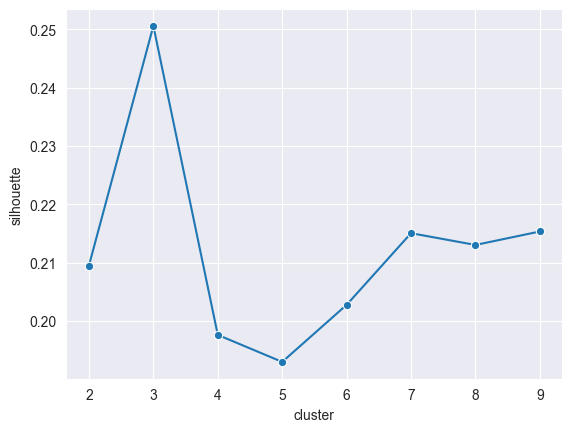

In [12]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.predict(X))
    return silhouette

silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X_norm))
    silhouette_res["cluster"].append(cluster_num)

silhouette_df = pd.DataFrame(silhouette_res)

sns.set_style("darkgrid")
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [14]:
k_means =  KMeans(n_clusters=3, random_state=42, init='random')
k_means.fit(X_norm)

y_pred = k_means.predict(X_norm)
y_pred = pd.DataFrame(y_pred, columns=['cluster'])
y_pred.value_counts()

cluster
2          6119
1          1596
0          1235
Name: count, dtype: int64

In [21]:
dbscan = DBSCAN()
y_pred = dbscan.fit_predict(X_norm)
y_pred = pd.DataFrame(y_pred, columns=['cluster'])
y_pred.value_counts()

cluster
-1         6627
 0         1698
 5          234
 11          60
 2           34
 17          30
 15          23
 8           23
 16          18
 9           14
 7           13
 3           11
 31          10
 6            9
 23           9
 1            8
 28           8
 10           8
 21           7
 19           7
 29           7
 12           7
 14           6
 4            6
 25           6
 13           6
 33           5
 32           5
 30           5
 18           5
 27           5
 26           5
 24           5
 22           5
 20           5
 37           5
 34           4
 36           4
 35           3
Name: count, dtype: int64

In [31]:
def get_silhouette(eps, min_samples, X):
    clustering =  DBSCAN(eps=eps, min_samples=min_samples)
    silhouette = silhouette_score(X, clustering.fit_predict(X))
    return silhouette

silhouette_res = {"silhouette": [], "params": []}

for eps in np.arange(0.1, 3, 0.2):
    for min_samples in range(1, 20, 4):
        silhouette_res["silhouette"].append(get_silhouette(eps, min_samples, X_norm))
        silhouette_res["params"].append((eps, min_samples))

silhouette_df = pd.DataFrame(silhouette_res)

<Axes: xlabel='cluster', ylabel='silhouette'>

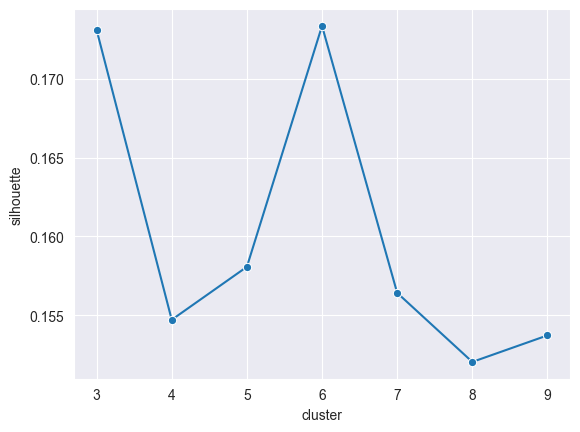

In [34]:
def get_silhouette(cluster_num, X):
    ag_clustering =  AgglomerativeClustering(n_clusters=cluster_num)
    silhouette = silhouette_score(X, ag_clustering.fit_predict(X))
    return silhouette

silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(3, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, X_norm))
    silhouette_res["cluster"].append(cluster_num)

silhouette_df = pd.DataFrame(silhouette_res)

sns.set_style("darkgrid")
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [35]:
ag_clustering =  AgglomerativeClustering(n_clusters=6)
y_pred = ag_clustering.fit_predict(X_norm)
y_pred = pd.DataFrame(y_pred, columns=['cluster'])
y_pred.value_counts()

cluster
0          3946
1          2931
2           864
5           722
3           464
4            23
Name: count, dtype: int64